In [1]:
import numpy as np 
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix,classification_report
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

In [2]:
titanic=pd.read_csv("/kaggle/input/datasets/fatuzahra/titanic/titanic.csv")
titanic.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [3]:
titanic["Age"].fillna(
    titanic["Age"].mean(),inplace=True
)
titanic.isnull().sum()

/tmp/ipykernel_17/3602136534.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  titanic["Age"].fillna(


PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age              0
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [4]:
titanic["Embarked"].fillna(
    titanic["Embarked"].mode()[0], inplace=True
)
titanic.isnull().sum()

/tmp/ipykernel_17/3234954753.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  titanic["Embarked"].fillna(


PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age              0
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         0
dtype: int64

In [5]:
titanic= titanic.drop(columns="Cabin")

titanic.isnull().sum()

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64

In [6]:
titanic=titanic[['Survived','Pclass','Age','Fare','Sex']]

titanic['Age'].fillna(titanic['Age'].median(),inplace=True)

/tmp/ipykernel_17/1787994337.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  titanic['Age'].fillna(titanic['Age'].median(),inplace=True)


In [7]:
titanic['Sex']=titanic['Sex'].map({'male':0,'female':1})

In [8]:
X= titanic.drop('Survived',axis=1)
Y=titanic['Survived']

In [9]:
X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y,
    test_size=0.2,
    random_state=42
)

In [10]:
models={
    "KNN": KNeighborsClassifier(n_neighbors=5),
    "Decision Tree": DecisionTreeClassifier(max_depth=5),
    "Random Forest": RandomForestClassifier(n_estimators=100)
}

In [11]:
for name, model in models.items():
    model.fit(X_train,Y_train)
    predics=model.predict(X_test)
    accuracy=accuracy_score(Y_test,predics)
    print(f'{name} Accuracy:',accuracy)

KNN Accuracy: 0.6983240223463687
Decision Tree Accuracy: 0.8044692737430168
Random Forest Accuracy: 0.7988826815642458


In [12]:
scaler=StandardScaler()
X_train_scaled=scaler.fit_transform(X_train)
X_test_scaled=scaler.transform(X_test)

knn_scaled=KNeighborsClassifier(n_neighbors=5)
knn_scaled.fit(X_train_scaled,Y_train)

predics_knn_scaled=knn_scaled.predict(X_test_scaled)
accuracy_knn_scaled=accuracy_score(Y_test,predics_knn_scaled)

print("KNN Accuracy after scaling:",accuracy_knn_scaled)

KNN Accuracy after scaling: 0.8212290502793296


In [13]:
param_grid={
    'n_estimators':[50,100],
    'max_depth':[None,5,10],
    'min_samples_split':[2,5]
}

rf=RandomForestClassifier(random_state=42)

In [14]:
grid=GridSearchCV(
    rf,
    param_grid,
    cv=5,
    scoring="accuracy"
)

In [15]:
grid.fit(X_train,Y_train)

GridSearchCV(cv=5, estimator=RandomForestClassifier(random_state=42),
             param_grid={'max_depth': [None, 5, 10],
                         'min_samples_split': [2, 5],
                         'n_estimators': [50, 100]},
             scoring='accuracy')

In [16]:
print('Best parameters:',grid.best_params_)
print('Best Accuracy:',grid.best_score_)

Best parameters: {'max_depth': 10, 'min_samples_split': 2, 'n_estimators': 100}
Best Accuracy: 0.8342854328769821


In [17]:
# KMeansALgorithm 

# Helps in clustring 
# P.S Clustering means grouping on the basis of common characteristics, discovering patterns

# The value of n_cluster defines how many clusters will be made in the dataset
# Follows distance formula
# Centriod is the mid point of a cluster
# The distance of each datapoint to the centriod is measured
# The datapoint is allotted to the clusters whose centroid is nearest to that datapoint

# In the first attempt the centroid is chosen randomly
# After that, the centroids are updated
# The midpoint of a cluster is calculated,
# It is decalred as the new centroid,
# The distance from each datapoint is measured again
# This process is repeated until the centroid is exactly at the centre of the cluster

# Scaling is essential just like in KNN because KMeans also depends on distance formula

In [18]:
scaler=StandardScaler()
X_scaled=scaler.fit_transform(X)
kmeans=KMeans(n_clusters=2,random_state=42)
clusters=kmeans.fit_predict(X_scaled)
titanic['Clusters']=clusters
titanic.head()


,Survived,Pclass,Age,Fare,Sex,Clusters
0,0,3,22.0,7.2500,0,0
1,1,1,38.0,71.2833,1,1
2,1,3,26.0,7.9250,1,0
3,1,1,35.0,53.1000,1,1
4,0,3,35.0,8.0500,0,0


In [19]:
wcss=[]

for k in range(1,11):
    kmeans=KMeans(n_clusters=k,random_state=42)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

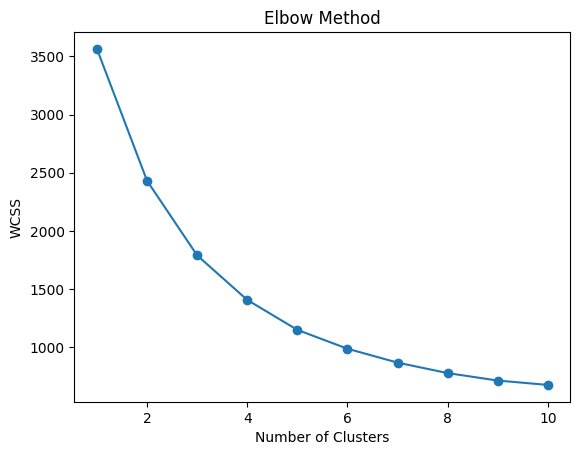

In [20]:
plt.plot(range(1,11),wcss,marker='o')
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.title("Elbow Method")
plt.show()

In [21]:
score=silhouette_score(X_scaled,clusters)
print("Silhouette Score:",score)

Silhouette Score: 0.39633853812209874


In [22]:
for k in range( 2, 8):
    kmeans = KMeans(n_clusters = k, random_state = 42)
    labels = kmeans.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels)
    print(f"k = {k}, Score: {score}")

k = 2, Score: 0.39633853812209874
k = 3, Score: 0.42107929601839794
k = 4, Score: 0.4403750428358645
k = 5, Score: 0.45789319130474443
k = 6, Score: 0.4549115750517094
k = 7, Score: 0.4191245572106741


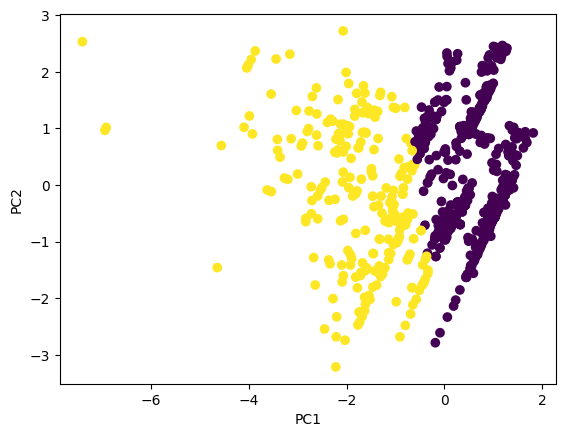

In [23]:
pca=PCA(n_components=2)
X_pca=pca.fit_transform(X_scaled)

plt.scatter(X_pca[:,0],X_pca[:,1],c=clusters)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()

In [24]:
scaler=StandardScaler()
X_scaled=scaler.fit_transform(X)
kmeans=KMeans(n_clusters=5,random_state=42)
clusters=kmeans.fit_predict(X_scaled)
titanic['Clusters']=clusters
titanic.head()


,Survived,Pclass,Age,Fare,Sex,Clusters
0,0,3,22.0,7.2500,0,0
1,1,1,38.0,71.2833,1,4
2,1,3,26.0,7.9250,1,2
3,1,1,35.0,53.1000,1,4
4,0,3,35.0,8.0500,0,0


In [25]:
wcss=[]

for k in range(1,11):
    kmeans=KMeans(n_clusters=k,random_state=42)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

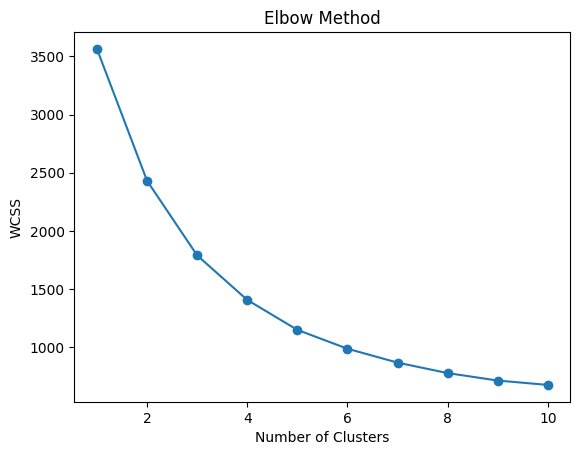

In [26]:
plt.plot(range(1,11),wcss,marker='o')
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.title("Elbow Method")
plt.show()

In [27]:
score=silhouette_score(X_scaled,clusters)
print("Silhouette Score:",score)

Silhouette Score: 0.45789319130474443


In [28]:
for k in range( 2, 8):
    kmeans = KMeans(n_clusters = k, random_state = 42)
    labels = kmeans.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels)
    print(f"k = {k}, Score: {score}")

k = 2, Score: 0.39633853812209874
k = 3, Score: 0.42107929601839794
k = 4, Score: 0.4403750428358645
k = 5, Score: 0.45789319130474443
k = 6, Score: 0.4549115750517094
k = 7, Score: 0.4191245572106741


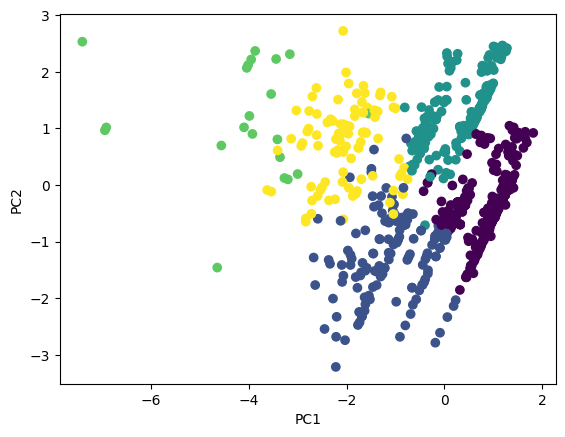

In [29]:
pca = PCA(n_components = 2)
X_pca = pca.fit_transform(X_scaled)

plt.scatter(X_pca[:,0], X_pca[:,1], c= clusters)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()